In [75]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from matplotlib.patches import Rectangle

In [41]:
# read file into df
df = pd.read_parquet('compiled_data.parquet', engine='fastparquet')
df.head()

,SEQN,gender,age,pregnancy_status,reported_race,2_year_interview_weight,2_year_mec_exam_weight,heart_rate,diastolic_bp_1,diastolic_bp_2,...,dpq_3,dpq_4,dpq_5,dpq_6,dpq_7,dpq_8,dpq_9,dpq_total,depression_category,depression_binary
0,93705.0,2.0,66.0,NaN,4.0,8614.571172,8338.419786,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Minimal or no depression,False
1,93706.0,1.0,18.0,NaN,6.0,8548.632619,8723.439814,NaN,74.0,70.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Minimal or no depression,False
2,93708.0,2.0,66.0,NaN,6.0,13329.450589,14372.488765,NaN,NaN,78.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Minimal or no depression,False
3,93711.0,1.0,56.0,NaN,6.0,11178.260106,12390.919724,NaN,68.0,68.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,Minimal or no depression,False
4,93712.0,1.0,18.0,NaN,1.0,29040.496558,30336.654325,NaN,68.0,72.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Minimal or no depression,False


In [42]:
# print shape and info
print(df.columns)

Index(['SEQN', 'gender', 'age', 'pregnancy_status', 'reported_race',
       '2_year_interview_weight', '2_year_mec_exam_weight', 'heart_rate',
       'diastolic_bp_1', 'diastolic_bp_2', 'diastolic_bp_3', 'mil',
       'systolic_bp_1', 'systolic_bp_2', 'systolic_bp_3', 'bmi',
       'basophil_count', 'eosinophil_count', 'lymphocyte_count',
       'monocyte_count', 'neutrophil_count', 'basophil_perc',
       'eosinophil_perc', 'hematocrit', 'hemoglobin', 'lymphocyte_perc',
       'mean_cell_hemoglobin_concentration', 'mean_cell_hemoglobin',
       'mean_cell_volume', 'monocyte_perc', 'mean_platelet_vol',
       'neutrophil_perc', 'nucleated_red_blodd_cells', 'platelet_count',
       'red_blood_cell_count', 'red_cell_distribution_width',
       'white_blood_cell_count', 'c_reactive_protein', 'albumin',
       'total_cholesterol_mmol_liter', 'globulin_g_liter',
       'glucose_mmol_liter', 'total_cholesterol_mg_dl', 'albumin_g_dl',
       'glucose_mg_dl', 'triglycerides', 'ferritin_microgr

In [43]:
df.dtypes.value_counts()

float64    95
object      1
bool        1
Name: count, dtype: int64

In [44]:
# print top 5 rows of each column
print(df.depression_category.value_counts())

depression_category
Minimal or no depression        3772
Mild depression                  837
Moderate depression              292
Moderately severe depression     124
Severe depression                 43
Name: count, dtype: int64


In [45]:
depression_map = {
    'Minimal or no depression':0,
    'Mild depression':1,
    'Moderate depression':2,
    'Moderately severe depression':2,
    'Severe depression':2
}
df["dep_score"] = df['depression_category'].map(depression_map)
print(df["dep_score"].value_counts())

dep_score
0    3772
1     837
2     459
Name: count, dtype: int64


In [46]:
print(df.dtypes.value_counts())

float64    95
object      1
bool        1
int64       1
Name: count, dtype: int64


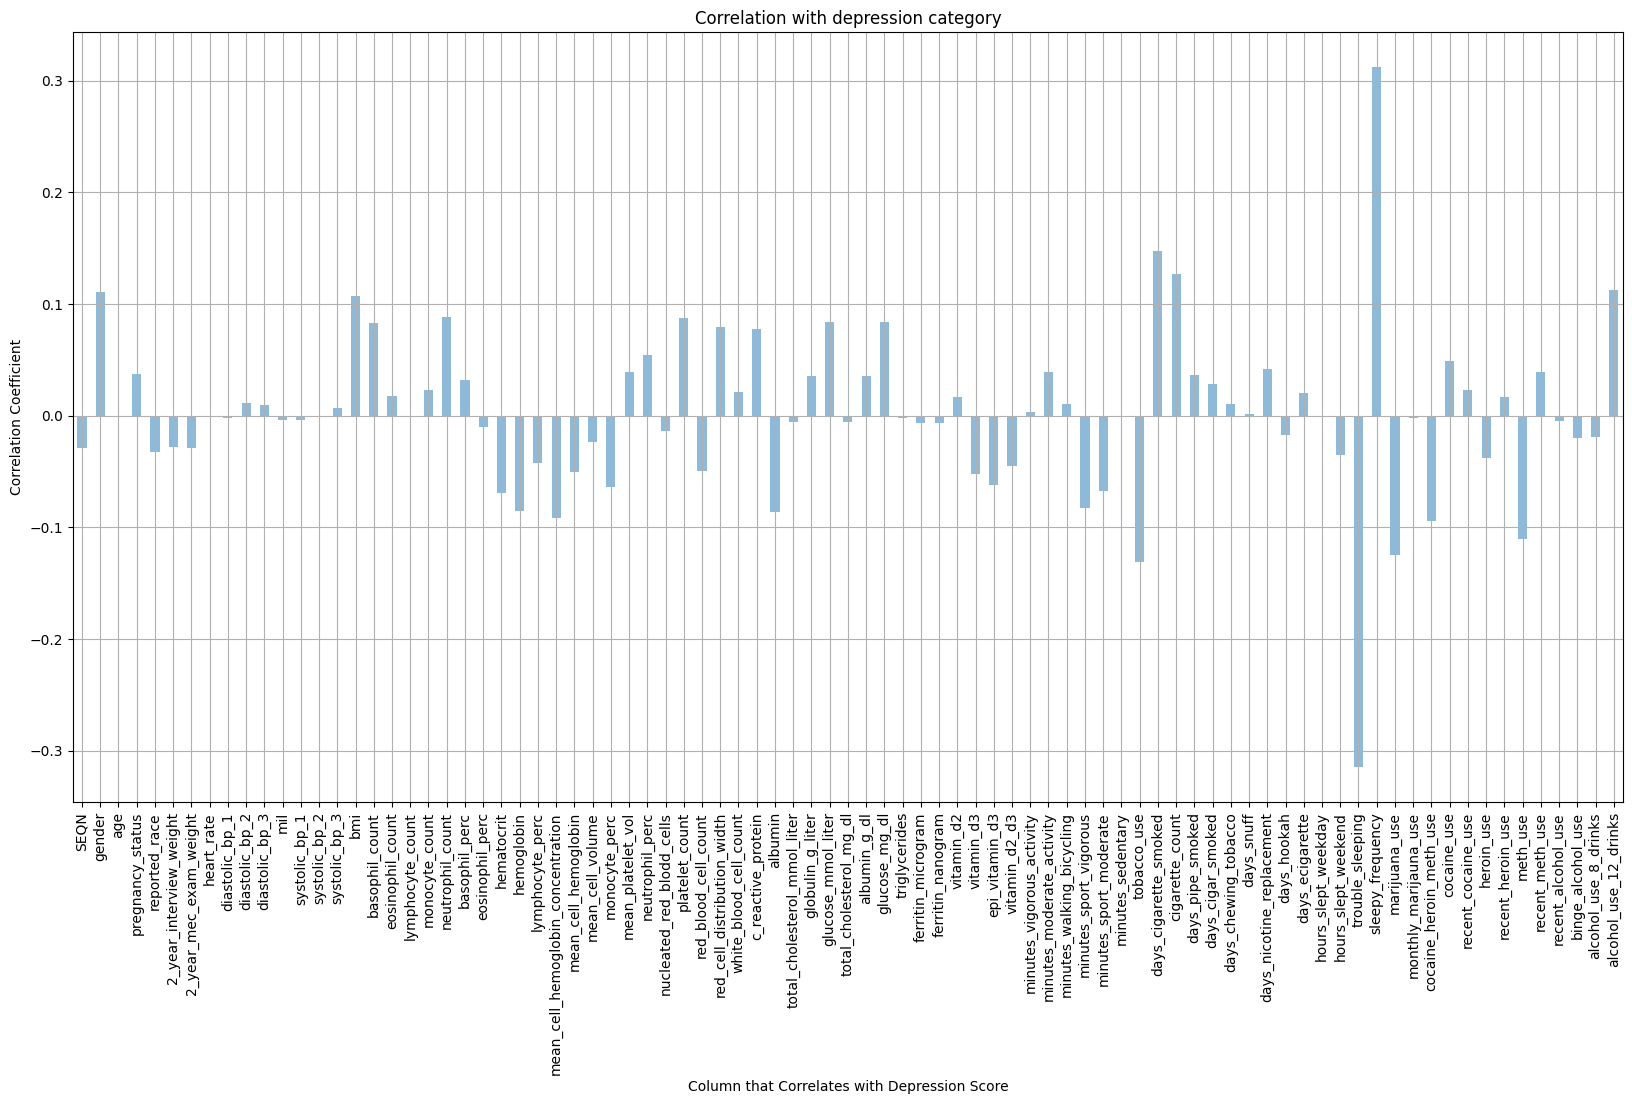

In [99]:
#drop dpq columns
df = df.loc[:, ~df.columns.str.contains("dpq")]
X_train, X_test_val, Y_train, Y_test_val = train_test_split(df.iloc[:, :-1], df["dep_score"], test_size=0.4, random_state=1234)
#Create dataframe from training data for EDA
df_train = pd.concat([X_train, Y_train], axis=1)

#Select numeric columns to allow for correlation calculation and graphing
numeric_df = df_train.select_dtypes(include=['float64', 'int64'])
correlations = numeric_df.corrwith(numeric_df.dep_score)
correlations.iloc[:-1].plot(kind='bar', title=f'Correlation with depression category', figsize=(20,10), grid = True, alpha = 0.5)
plt.xlabel('Column that Correlates with Depression Score')
plt.ylabel('Correlation Coefficient')
plt.show()

Text(0.5, 0, 'Depression Score')

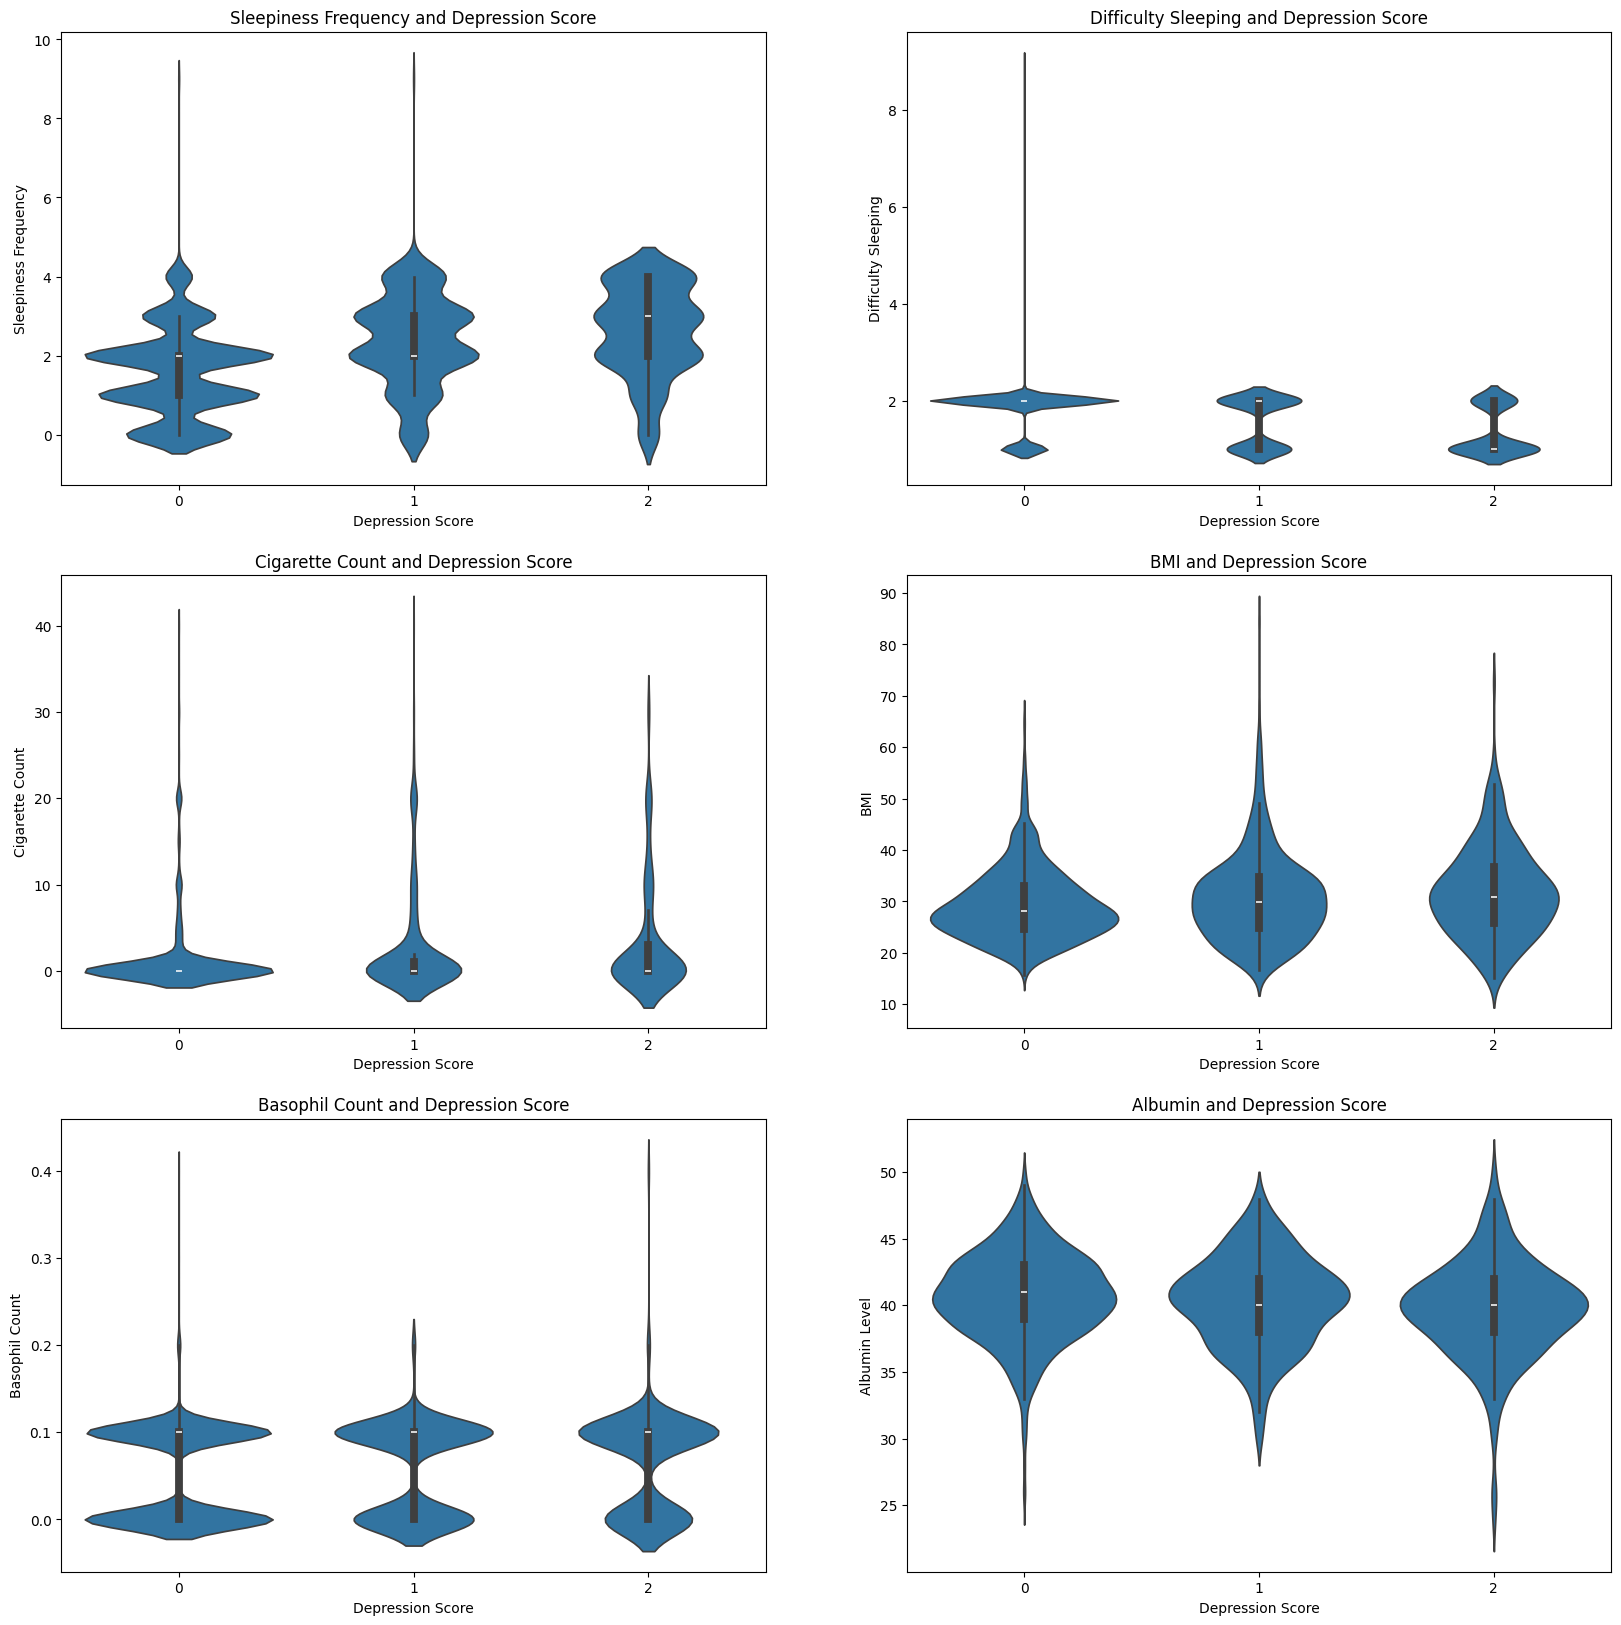

In [101]:
fig, axes = plt.subplots(3, 2, figsize=(20, 20))
sns.violinplot(ax = axes[0,0], data = numeric_df, x='dep_score', y='sleepy_frequency')
axes[0,0].set_title('Sleepiness Frequency and Depression Score')
axes[0,0].set_ylabel("Sleepiness Frequency")
axes[0,0].set_xlabel("Depression Score")
sns.violinplot(ax = axes[0,1], data = numeric_df, x='dep_score', y='trouble_sleeping')
axes[0,1].set_title('Difficulty Sleeping and Depression Score')
axes[0,1].set_ylabel("Difficulty Sleeping")
axes[0,1].set_xlabel("Depression Score")
sns.violinplot(ax = axes[1,0], data = numeric_df, x='dep_score', y='cigarette_count')
axes[1,0].set_title('Cigarette Count and Depression Score')
axes[1,0].set_ylabel("Cigarette Count")
axes[1,0].set_xlabel("Depression Score")
sns.violinplot(ax = axes[1,1], data = numeric_df, x='dep_score', y='bmi')
axes[1,1].set_title('BMI and Depression Score')
axes[1,1].set_ylabel("BMI")
axes[1,1].set_xlabel("Depression Score")
sns.violinplot(ax = axes[2,0], data = numeric_df, x='dep_score', y='basophil_count')
axes[2,0].set_title('Basophil Count and Depression Score')
axes[2,0].set_ylabel("Basophil Count")
axes[2,0].set_xlabel("Depression Score")
sns.violinplot(ax = axes[2,1], data = numeric_df, x='dep_score', y='albumin')
axes[2,1].set_title('Albumin and Depression Score')
axes[2,1].set_ylabel("Albumin Level")
axes[2,1].set_xlabel("Depression Score")

<function matplotlib.pyplot.show(close=None, block=None)>

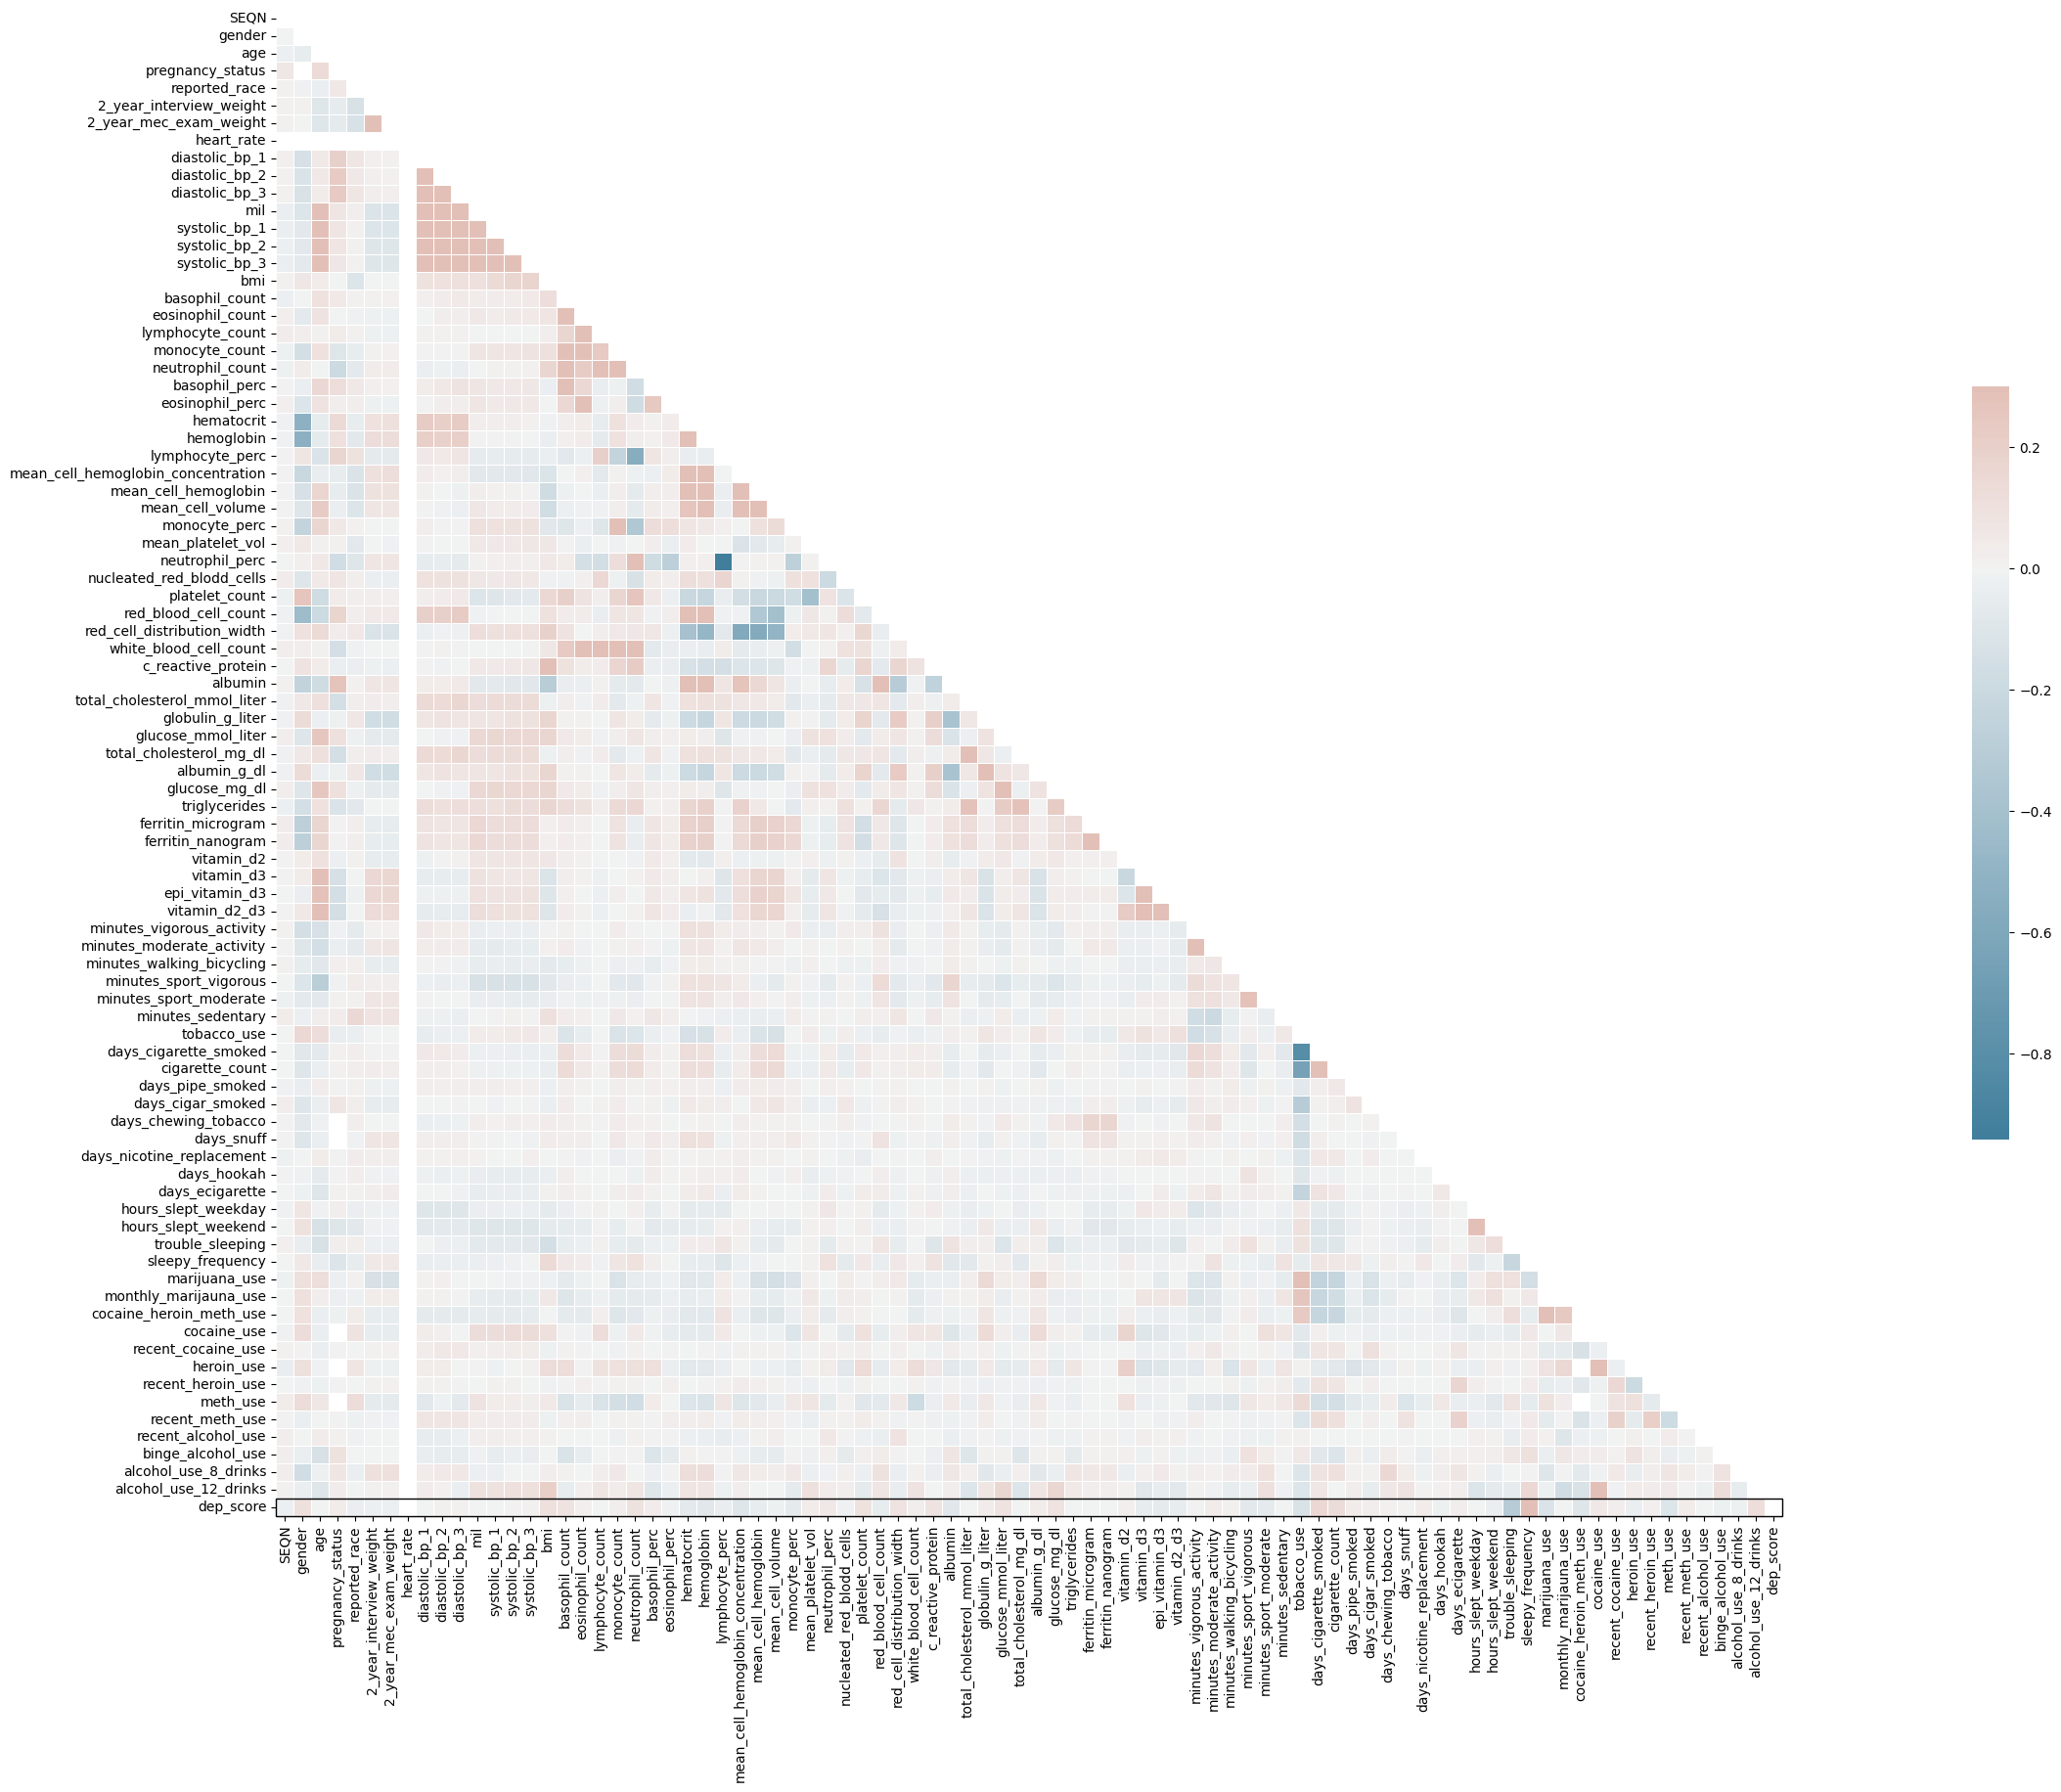

In [91]:

corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
f, ax = plt.subplots(figsize=(50, 20))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
ax = sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=False)
ax.add_patch(Rectangle((0,len(corr)-1), width=len(corr), height=1, fill=False, edgecolor='black', lw=1, clip_on=False))
plt.show

In [73]:
len(corr)

86